1. Read the data

In [2]:
import pandas as pd

# Read the dataset
df = pd.read_csv(
    r"C:\Users\shade\OneDrive\Documents\Samsung Bootcamp\Project\Customer-Support-Tickets\Prompted\data\final_ml_ready_support_tickets.csv"
)
# Check the dataset shape
print(df.shape)

# Display column names
print(df.columns.tolist())

(17217, 19)
['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8', 'norm_subj', 'norm_body', 'ticket_key']


2. Explore the data

In [3]:
# Display the first five rows
df.head()

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,norm_subj,norm_body,ticket_key
0,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN,account disruption,"dear customer support team,\n\ni am writing to...",account disruption || dear customer support te...
1,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN,query about smart home system integration feat...,"dear customer support team,\n\ni hope this mes...",query about smart home system integration feat...
2,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN,inquiry regarding invoice details,"dear customer support team,\n\ni hope this mes...",inquiry regarding invoice details || dear cust...
3,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN,question about marketing agency software compa...,"dear support team,\n\ni hope this message reac...",question about marketing agency software compa...
4,Feature Query,"Dear Customer Support,\n\nI hope this message ...",Thank you for your inquiry. Please specify whi...,Request,Technical Support,high,en,51.0,Feature,Product,Documentation,Feedback,NaN,NaN,NaN,NaN,feature query,"dear customer support,\n\ni hope this message ...","feature query || dear customer support,\n\ni h..."


In [4]:
# Check data types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17217 entries, 0 to 17216
Data columns (total 19 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   subject     17217 non-null  str    
 1   body        17217 non-null  str    
 2   answer      17213 non-null  str    
 3   type        17217 non-null  str    
 4   queue       17217 non-null  str    
 5   priority    17217 non-null  str    
 6   language    17217 non-null  str    
 7   version     10029 non-null  float64
 8   tag_1       17217 non-null  str    
 9   tag_2       17203 non-null  str    
 10  tag_3       17154 non-null  str    
 11  tag_4       15928 non-null  str    
 12  tag_5       11094 non-null  str    
 13  tag_6       6167 non-null   str    
 14  tag_7       3195 non-null   str    
 15  tag_8       1448 non-null   str    
 16  norm_subj   17217 non-null  str    
 17  norm_body   17217 non-null  str    
 18  ticket_key  17217 non-null  str    
dtypes: float64(1), str(18)
memory usage:

In [5]:
# Check missing values in important columns
df[["subject", "body", "type", "priority"]].isnull().sum()

subject     0
body        0
type        0
priority    0
dtype: int64

In [6]:
# Check the distribution of issue types
df["type"].value_counts()

type
Incident    6843
Request     5028
Problem     3555
Change      1791
Name: count, dtype: int64

3. Create the text feature

In [7]:
# Combine subject and body into a single text column
df["text"] = (
    df["subject"].fillna("") + " " +
    df["body"].fillna("")
)

# Check the combined text
df[["subject", "body", "text", "type"]].head()

,subject,body,text,type
0,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Account Disruption Dear Customer Support Team,...",Incident
1,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Query About Smart Home System Integration Feat...,Request
2,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",Inquiry Regarding Invoice Details Dear Custome...,Request
3,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Question About Marketing Agency Software Compa...,Problem
4,Feature Query,"Dear Customer Support,\n\nI hope this message ...","Feature Query Dear Customer Support,\n\nI hope...",Request


4. Define features and target

In [8]:
# Define the input features
X = df["text"]

# Define the target variable
y = df["type"]

5. Split the data

In [9]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Check the number of samples in each set
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 13773
Testing samples: 3444


6. Convert text into TF-IDF features

TF-IDF converts text into numerical features that a machine learning model can understand.

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create the TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2)
)

# Learn the vocabulary from the training data and transform it
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform the test data using the same vocabulary
X_test_tfidf = tfidf.transform(X_test)

# Check the resulting dimensions
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (13773, 20000)
Testing TF-IDF shape: (3444, 20000)


7. Build the first ML model

Logistic Regression learns the relationship between the text features and the ticket category.

In [11]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

# Train the model
model.fit(X_train_tfidf, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

8. Make predictions

In [12]:
# Predict issue types for the test data
y_pred = model.predict(X_test_tfidf)

9. Evaluate the model

In [13]:
from sklearn.metrics import accuracy_score, classification_report

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

# Display precision, recall, and F1-score
print(classification_report(y_test, y_pred))

Accuracy: 0.8141695702671312
              precision    recall  f1-score   support

      Change       0.96      0.94      0.95       358
    Incident       0.81      0.73      0.77      1369
     Problem       0.56      0.67      0.61       711
     Request       0.98      0.99      0.98      1006

    accuracy                           0.81      3444
   macro avg       0.83      0.83      0.83      3444
weighted avg       0.82      0.81      0.82      3444



10. Confusion Matrix

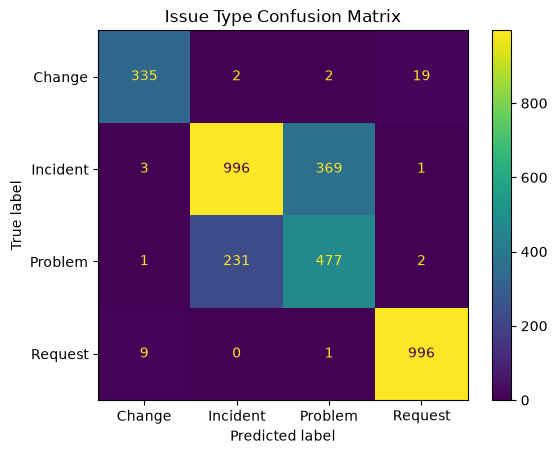

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Display the confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Issue Type Confusion Matrix")
plt.show()

We already have the TF-IDF features. Now, we will train another machine learning model, Linear SVM, and compare its performance with Logistic Regression.

LinearSVC is used to build a Linear Support Vector Machine classifier.

1. Import Linear SVM

In [15]:
from sklearn.svm import LinearSVC

2. Create the model

We use class_weight="balanced" because our classes are not perfectly balanced. This gives more importance to classes with fewer samples.

In [16]:
# Create the Linear SVM model
svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42
)

3. Train the model

In [17]:
# Train the model
svm_model.fit(X_train_tfidf, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`inte

The model learns the relationship between the TF-IDF features and the correct issue type labels.

4. Make predictions

In [18]:
# Predict issue types for the test data
svm_pred = svm_model.predict(X_test_tfidf)

After training, we use the model to predict the issue type of unseen test tickets.

5. Evaluate the model

In [19]:
from sklearn.metrics import accuracy_score, classification_report, f1_score

# Calculate accuracy
svm_accuracy = accuracy_score(y_test, svm_pred)

# Calculate Macro-F1
svm_macro_f1 = f1_score(y_test, svm_pred, average="macro")

print("SVM Accuracy:", svm_accuracy)
print("SVM Macro-F1:", svm_macro_f1)

# Display detailed classification metrics
print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.8388501742160279
SVM Macro-F1: 0.8450333131211882
              precision    recall  f1-score   support

      Change       0.98      0.95      0.96       358
    Incident       0.80      0.81      0.81      1369
     Problem       0.63      0.61      0.62       711
     Request       0.98      0.99      0.99      1006

    accuracy                           0.84      3444
   macro avg       0.85      0.84      0.85      3444
weighted avg       0.84      0.84      0.84      3444



We evaluate the model using Accuracy, Precision, Recall, F1-score, and Macro-F1.

Macro-F1 is particularly useful here because it gives equal importance to all issue types.

6. Compare with Logistic Regression

In [20]:
# Calculate Macro-F1 for Logistic Regression
lr_macro_f1 = f1_score(y_test, y_pred, average="macro")

# Compare the two models
print("Logistic Regression Macro-F1:", lr_macro_f1)
print("Linear SVM Macro-F1:", svm_macro_f1)

Logistic Regression Macro-F1: 0.8278700831007321
Linear SVM Macro-F1: 0.8450333131211882


We compare the Macro-F1 scores of both models. The model with the higher Macro-F1 performs better in terms of balanced classification across the four issue types.

Naive Bayes predicts the class by estimating the probability of each class based on the features in the text.

In [21]:
from sklearn.naive_bayes import MultinomialNB

# Create the Multinomial Naive Bayes model
nb_model = MultinomialNB()

# Train the model
nb_model.fit(X_train_tfidf, y_train)

# Predict issue types for the test data
nb_pred = nb_model.predict(X_test_tfidf)

In [22]:
from sklearn.metrics import accuracy_score, classification_report, f1_score

# Calculate accuracy
nb_accuracy = accuracy_score(y_test, nb_pred)

# Calculate Macro-F1
nb_macro_f1 = f1_score(y_test, nb_pred, average="macro")

print("Naive Bayes Accuracy:", nb_accuracy)
print("Naive Bayes Macro-F1:", nb_macro_f1)

# Display detailed classification metrics
print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.7752613240418118
Naive Bayes Macro-F1: 0.6865589149716125
              precision    recall  f1-score   support

      Change       1.00      0.69      0.82       358
    Incident       0.67      0.98      0.80      1369
     Problem       0.76      0.10      0.18       711
     Request       0.91      1.00      0.95      1006

    accuracy                           0.78      3444
   macro avg       0.84      0.69      0.69      3444
weighted avg       0.79      0.78      0.72      3444



In [23]:
# Compare the Macro-F1 scores of all models
print("Logistic Regression:", lr_macro_f1)
print("Linear SVM:", svm_macro_f1)
print("Naive Bayes:", nb_macro_f1)

Logistic Regression: 0.8278700831007321
Linear SVM: 0.8450333131211882
Naive Bayes: 0.6865589149716125


Linear SVM achieved the highest Macro-F1 score of 0.845, so it is currently the best-performing model among the three models we tested.

In [24]:
from sklearn.linear_model import SGDClassifier

# Create the SGD classifier
sgd_model = SGDClassifier(
    loss="hinge",
    class_weight="balanced",
    random_state=42
)

# Train the model
sgd_model.fit(X_train_tfidf, y_train)

# Predict issue types for the test data
sgd_pred = sgd_model.predict(X_test_tfidf)

In [25]:
# Calculate the Macro-F1 score
sgd_macro_f1 = f1_score(y_test, sgd_pred, average="macro")

print("SGD Macro-F1:", sgd_macro_f1)

# Display detailed classification metrics
print(classification_report(y_test, sgd_pred))

SGD Macro-F1: 0.8277205766886522
              precision    recall  f1-score   support

      Change       0.97      0.94      0.95       358
    Incident       0.78      0.81      0.79      1369
     Problem       0.60      0.55      0.57       711
     Request       0.98      0.99      0.99      1006

    accuracy                           0.82      3444
   macro avg       0.83      0.82      0.83      3444
weighted avg       0.82      0.82      0.82      3444



SGD is another linear classifier. We test it to see whether it can perform better than Logistic Regression and Linear SVM on our text classification task.

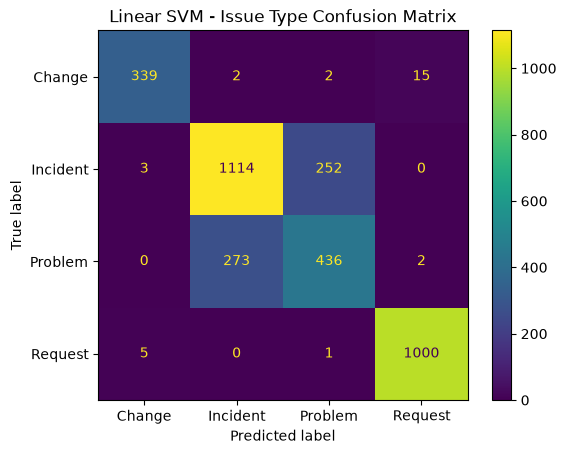

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Display the confusion matrix for the best model
ConfusionMatrixDisplay.from_predictions(
    y_test,
    svm_pred
)

plt.title("Linear SVM - Issue Type Confusion Matrix")
plt.show()

“The Linear SVM achieved the best Macro-F1 among our tested models. The confusion matrix shows that the main classification challenge is distinguishing between Incident and Problem tickets.”

In [27]:
# Create a dataframe for the test predictions
results = pd.DataFrame({
    "text": X_test,
    "true_type": y_test,
    "predicted_type": svm_pred
})

# Find Incident tickets incorrectly predicted as Problem
incident_problem = results[
    (results["true_type"] == "Incident") &
    (results["predicted_type"] == "Problem")
]

# Display 10 examples
incident_problem.head(10)

,text,true_type,predicted_type
363,Immediate Attention Needed: Malfunction in Cru...,Incident,Problem
7786,Support Brand Engagement Concern Noticing a de...,Incident,Problem
2159,Security Breach Concern in Healthcare Systems ...,Incident,Problem
3949,Unauthorized Intrusion into Hospital Networks ...,Incident,Problem
1257,Hospital System Security Breach Customer Suppo...,Incident,Problem
1952,"Data Security Breach Concern Customer Support,...",Incident,Problem
11682,Support Request for Data Encryption Issue I am...,Incident,Problem
10190,Investment Forecasts Did Not Meet Expectations...,Incident,Problem
3113,Support Needed for Data Analytics System Optim...,Incident,Problem
3015,Reported Access Problems for Healthcare Provid...,Incident,Problem


In [28]:
# Create a dataframe for all predictions
results = pd.DataFrame({
    "text": X_test,
    "true_type": y_test,
    "predicted_type": svm_pred
})

# Keep only misclassified tickets
errors = results[
    results["true_type"] != results["predicted_type"]
].copy()

print("Total test tickets:", len(results))
print("Misclassified tickets:", len(errors))
print("Error rate:", len(errors) / len(results))

Total test tickets: 3444
Misclassified tickets: 555
Error rate: 0.16114982578397213


In [29]:
# Count the most common misclassification pairs
error_pairs = (
    errors
    .groupby(["true_type", "predicted_type"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

error_pairs

,true_type,predicted_type,count
5,Problem,Incident,273
4,Incident,Problem,252
2,Change,Request,15
7,Request,Change,5
3,Incident,Change,3
0,Change,Incident,2
1,Change,Problem,2
6,Problem,Request,2
8,Request,Problem,1


In [30]:
# Show errors for each actual class

for label in sorted(errors["true_type"].unique()):
    print(f"\n===== Actual: {label} =====")
    
    class_errors = errors[
        errors["true_type"] == label
    ]
    
    print(
        class_errors["predicted_type"]
        .value_counts()
    )


===== Actual: Change =====
predicted_type
Request     15
Incident     2
Problem      2
Name: count, dtype: int64

===== Actual: Incident =====
predicted_type
Problem    252
Change       3
Name: count, dtype: int64

===== Actual: Problem =====
predicted_type
Incident    273
Request       2
Name: count, dtype: int64

===== Actual: Request =====
predicted_type
Change     5
Problem    1
Name: count, dtype: int64


Examples

In [31]:
incident_problem = errors[
    (errors["true_type"] == "Incident") &
    (errors["predicted_type"] == "Problem")
]

incident_problem[[
    "text",
    "true_type",
    "predicted_type"
]].head(10)

,text,true_type,predicted_type
363,Immediate Attention Needed: Malfunction in Cru...,Incident,Problem
7786,Support Brand Engagement Concern Noticing a de...,Incident,Problem
2159,Security Breach Concern in Healthcare Systems ...,Incident,Problem
3949,Unauthorized Intrusion into Hospital Networks ...,Incident,Problem
1257,Hospital System Security Breach Customer Suppo...,Incident,Problem
1952,"Data Security Breach Concern Customer Support,...",Incident,Problem
11682,Support Request for Data Encryption Issue I am...,Incident,Problem
10190,Investment Forecasts Did Not Meet Expectations...,Incident,Problem
3113,Support Needed for Data Analytics System Optim...,Incident,Problem
3015,Reported Access Problems for Healthcare Provid...,Incident,Problem


In [32]:
problem_incident = errors[
    (errors["true_type"] == "Problem") &
    (errors["predicted_type"] == "Incident")
]

problem_incident[[
    "text",
    "true_type",
    "predicted_type"
]].head(10)

,text,true_type,predicted_type
16418,Support Inquiry Regarding Data Analytics Dashb...,Problem,Incident
10325,Data Leak Incident An unexpected data leak has...,Problem,Incident
5337,Marketing Growth Challenges Increase The marke...,Problem,Incident
8357,Challenge in Lead Generation Our agency has fa...,Problem,Incident
16448,Unresolved Issue with Unpaid Invoices for Soft...,Problem,Incident
5778,Potential Data Compromise A potential data com...,Problem,Incident
15073,Inaccurate investment forecasts linked to pote...,Problem,Incident
5674,Facing Problems with Digital Marketing Softwar...,Problem,Incident
1536,Data Protection Concern A healthcare organizat...,Problem,Incident
9068,Assistance Needed with Investment Optimization...,Problem,Incident


In [37]:
import joblib

joblib.dump(tfidf, "Models/issue_type_tfidf.pkl")
joblib.dump(svm_model, "Models/issue_type_svm.pkl")

print("Issue Type model saved successfully.")

Issue Type model saved successfully.
